# 02 — Sentinel-2 snow/glacier proxy analysis
**Purpose:** retrieve and mask Sentinel-2, calculate NDSI, and build comparable 2017–2026 post-monsoon composites.  
**Inputs:** validated GLIMS ROI and centralized thresholds.  
**Outputs:** annual metrics CSV, time-series PNG, and representative-year HTML map.  
**Runtime:** Earth Engine reductions may take several minutes and may require `tile_scale` adjustment.  
**Dependencies:** authenticated Earth Engine session; run notebook 01 first or initialize below.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

%cd "/content/drive/MyDrive/langtang-glacier-ai"

Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai


In [3]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import ee
from src.config import SETTINGS
from src.gee_utils import build_rois, initialize_earth_engine
from src.glacier_features import build_annual_snow_series, feature_collection_to_dataframe, verify_sentinel2_availability
from src.utils import ensure_output_directories
from src.visualization import add_representative_composites, make_study_area_map, plot_snow_time_series
ensure_output_directories()
EE_PROJECT = "my-youtube-api-keys-453716"  # Google Earth Engine Project ID
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    initialize_earth_engine(
        project=EE_PROJECT,
        authenticate=True,
    )


The default window is October–November each year. Snow is an NDSI/brightness proxy within a fixed inventory ROI; it is not total glacier area, especially on debris-covered ice.

In [4]:
rois = build_rois()
archive_count = verify_sentinel2_availability(rois['glacier_roi'])
print(f'{archive_count} candidate Sentinel-2 scenes in configured archive window')
composites, annual_features = build_annual_snow_series(rois['glacier_roi'])
annual = feature_collection_to_dataframe(annual_features)
display(annual)


1018 candidate Sentinel-2 scenes in configured archive window


,date,mean_valid_observation_count,missing_data_flag,ndsi_mean,scene_count,snow_area_km2,snow_fraction_valid,valid_area_fraction,year,observation_count,expected_observation_count,period_completeness,is_complete_period,quality_status,quality_reason
0,2017-10-01,5.000000,0,0.278964,5,2.178126,0.418012,0.998432,2017,5.000000,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
1,2018-10-01,9.999924,0,0.250167,10,2.027925,0.389187,0.998432,2018,9.999924,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
2,2019-10-01,10.038331,0,0.346231,22,2.489277,0.477727,0.998432,2019,10.038331,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
3,2020-10-01,12.897611,0,0.258589,22,2.129699,0.408719,0.998432,2020,12.897611,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
4,2021-10-01,15.139452,0,0.368492,22,2.650353,0.508639,0.998432,2021,15.139452,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
5,2022-10-01,19.117359,0,0.405797,22,2.833786,0.543843,0.998432,2022,19.117359,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
6,2023-10-01,16.414094,0,0.326222,23,2.558765,0.491062,0.998432,2023,16.414094,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
7,2024-10-01,21.495386,0,0.248205,25,2.065011,0.396304,0.998432,2024,21.495386,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
8,2025-10-01,21.799347,0,0.494486,27,3.274217,0.628367,0.998432,2025,21.799347,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80


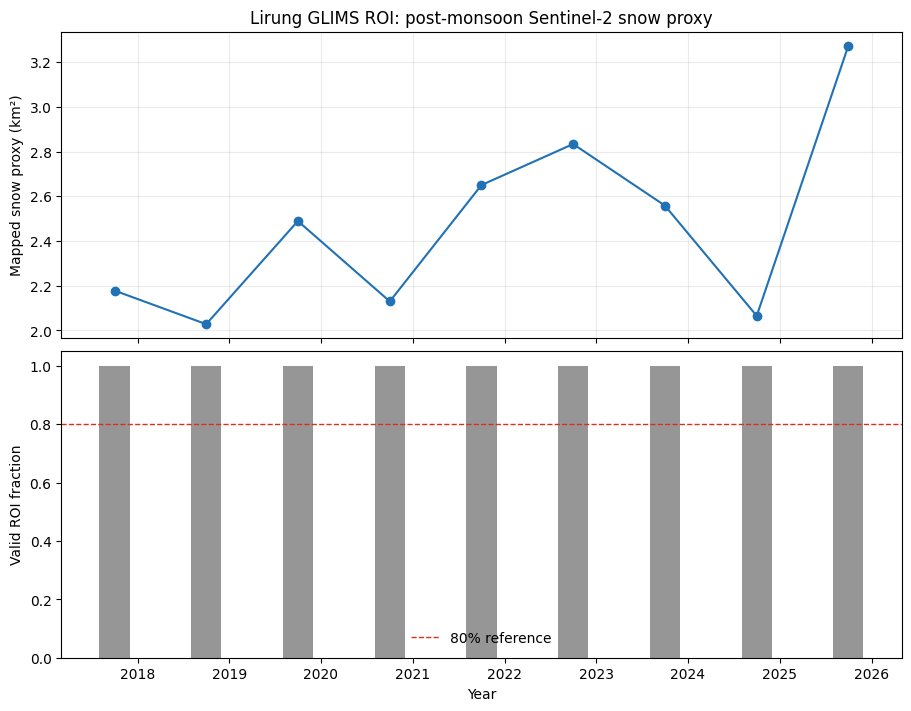

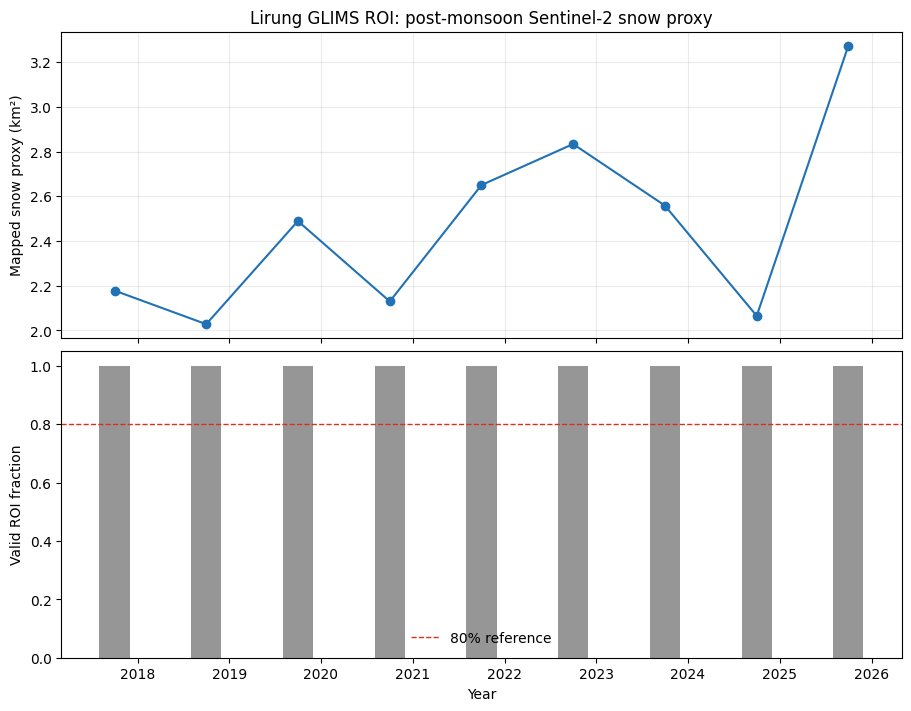

In [5]:
table_path = SETTINGS.output_tables / 'sentinel2_annual_snow_metrics.csv'
annual.to_csv(table_path, index=False)
fig = plot_snow_time_series(annual, SETTINGS.output_charts / 'sentinel2_post_monsoon_snow_proxy.png')
fig


In [6]:
comparison_map = make_study_area_map(rois)
add_representative_composites(comparison_map, composites)
comparison_map.to_html(str(SETTINGS.output_maps / 'sentinel2_representative_years.html'))
comparison_map


Map(center=[28.251882136909924, 85.54672799144113], controls=(WidgetControl(options=['position', 'transparent_…

## Quality checkpoint
Do not interpret a year with low `valid_area_fraction`, zero scenes, or sparse `mean_valid_observation_count`. Toggle RGB and NDSI layers to inspect cloud/shadow and terrain artifacts. No gaps are interpolated.